# Fisheries Conflict Analysis

## Load packages and data

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
import random
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import xarray as xr

In [8]:
# Load WWF data set
df = pd.read_excel('Merged_HOA_ARC_ECU_WCP_allViolenceScores.xlsx')

# Preview the data
print(df.head())

                source_file     event_id       date  year           country  \
0  Oceania_No_AUS_NZL_Final  24328612817 2011-12-01  2011    American Samoa   
1  Oceania_No_AUS_NZL_Final  24359251958 2011-10-12  2011  French Polynesia   
2  Oceania_No_AUS_NZL_Final  24349703891 2011-08-01  2011              Guam   
3  Oceania_No_AUS_NZL_Final  24327648295 2011-11-10  2011              Guam   
4  Oceania_No_AUS_NZL_Final  24359264846 2011-10-13  2011         High Seas   

    region                                           Location  latitude  \
0  Oceania              Pago Pago, capital of American Samoa. -14.27806   
1  Oceania                 Port of Papeete, French Polynesia. -17.53600   
2  Oceania               Hotel Wharf, Port Authority of Guam.  13.46000   
3  Oceania                      Agana and Agat Marinas, Guam.  13.47567   
4  Oceania  Pacific high seas, near several Pacific island... -14.47300   

   longitude   loc_accuracy  ... FoodInsecurity Marginalization  StratLoc 

## Exploratory Data Analysis

In [9]:
# check NAs
print(df.isna().sum())

source_file                    0
event_id                       0
date                           0
year                           0
country                        0
region                         0
Location                       0
latitude                       0
longitude                      0
loc_accuracy                 218
Actor1                         0
Actor2                         0
WeakGov                        0
FishPop                        0
EcoChngeOther                  0
GroundsLim                     0
ForeignFisher                  0
IllegalFishing                 0
IncrEfficiency                 0
IncrPressure                 156
OpsScales                      0
Markets                        0
Poverty                        0
FoodInsecurity                 0
Marginalization                0
StratLoc                       0
MaritimeCrime                  0
violence_score                 0
ViolenceScore_Explanation    902
Explanation                    0
Summary   

In [10]:
# Count frequency of violence_score counts
df['violence_score'].value_counts()

violence_score
1    464
2    461
3    133
Name: count, dtype: int64

In [11]:
#Frequency of regions
df['region'].value_counts()

region
Horn of Africa    684
Arctic            162
Oceania           154
South America      56
South Asia          2
Name: count, dtype: int64

In [12]:
df.dtypes

source_file                          object
event_id                             object
date                         datetime64[ns]
year                                  int64
country                              object
region                               object
Location                             object
latitude                            float64
longitude                           float64
loc_accuracy                         object
Actor1                               object
Actor2                               object
WeakGov                               int64
FishPop                               int64
EcoChngeOther                         int64
GroundsLim                            int64
ForeignFisher                         int64
IllegalFishing                        int64
IncrEfficiency                        int64
IncrPressure                        float64
OpsScales                             int64
Markets                               int64
Poverty                         

In [13]:
pd.crosstab(df['region'], df['violence_score'])

violence_score,1,2,3
region,,,
Arctic,125,37,0
Horn of Africa,247,317,120
Oceania,84,61,9
South America,8,44,4
South Asia,0,2,0


## Data Cleaning and Analysis

In [14]:
# Columns of interest for analysis
data = df[[
    "region",
    "WeakGov", 
    "FishPop", 
    "EcoChngeOther", 
    "GroundsLim", 
    "ForeignFisher", 
    "IllegalFishing", 
    "IncrEfficiency", 
    "OpsScales",
    "Markets",
    "Poverty",
    "FoodInsecurity",
    "Marginalization",
    "StratLoc",
    "MaritimeCrime",
    "violence_score"
]]

X = df[[
    "WeakGov", 
    "FishPop", 
    "EcoChngeOther", 
    "GroundsLim", 
    "ForeignFisher", 
    "IllegalFishing", 
    "IncrEfficiency", 
    "OpsScales",
    "Markets",
    "Poverty",
    "FoodInsecurity",
    "Marginalization",
    "StratLoc",
    "MaritimeCrime"   
]]

y = df['violence_score']

In [15]:
# Filter by region
def regional_filtering(data, region_string = None):
    if region_string is None:
        filtered = data
    elif region_string not in data['region'].values:
        valid_regions = data['region'].unique().tolist()
        raise ValueError(f"{region_string} is not a valid region in the dataset. These are the available options: {valid_regions}.")
    else:
        filtered = data[data['region'] == region_string]
    return filtered

# filtered = regional_filtering(data)

In [16]:
# Split data into training and testing groups
#Input: filtered data with 'region' variable from regional_filtering
def split_data(data):
    data2 = data.drop(columns = ['region'])
    X = data2.loc[:, data2.columns != 'violence_score']
    y = data2['violence_score']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2, random_state=42)
    return X_train, X_test, y_train, y_test

# X_train, X_test, y_train, y_test = split_data(data)
# X_test


In [17]:
def models(X_train, y_train):
    feature_names = X_train.columns 

    model_params = [
        {
            'name': 'Logistic Regression',
            'estimator': LogisticRegression(
                penalty='elasticnet',
                solver='saga',
                random_state=42,
                max_iter = 2500
            ),
            'param_grid': {
                'l1_ratio': np.linspace(0, 1, 5),
                'C': np.logspace(.01, 10, 5),
                'class_weight': [None, 'balanced']
            }
        },

        {
            'name': 'Random Forest',
            'estimator': RandomForestClassifier(class_weight = 'balanced', random_state=42),
            'param_grid': {
                'n_estimators': np.linspace(20, 250, 25).astype(int),
                'max_depth': [4, 7],
                'min_samples_split': [3, 5]
            }
        }
    ]

    cv_strategy = StratifiedKFold(n_splits = 5, shuffle=True, random_state=42) 
    scoring = {
        'accuracy': 'accuracy',
        'f1': 'f1_weighted',
        'roc_auc': 'roc_auc_ovr'}

    results = []

    for item in model_params:
        grid = GridSearchCV(
            item['estimator'],
            item['param_grid'],
            cv=cv_strategy,
            scoring=scoring,
            refit='accuracy',
            n_jobs = -1
        )

        grid.fit(X_train, y_train)

        model_name = item['name']

        
        for i, params in enumerate(grid.cv_results_['params']):

            # fit model for each parameter set
            temp_model = grid.estimator.set_params(**params)
            temp_model.fit(X_train, y_train)

            # feature selection per model
            if hasattr(temp_model, "coef_"): #for log reg
                coef = temp_model.coef_
                mask = np.any(np.abs(coef) > 1e-3, axis=0)

            elif hasattr(temp_model, "feature_importances_"): # for random forest
                importances = temp_model.feature_importances_
                mask = importances > 0

            else:
                mask = np.ones(len(feature_names), dtype=bool)

            selected_features = feature_names[mask]
            non_zero = np.sum(mask)

            results.append({
                'model': item['name'],
                'params': params,
                'training_data_accuracy': grid.cv_results_['mean_test_accuracy'][i],
                'f1': grid.cv_results_['mean_test_f1'][i],
                'roc_auc': grid.cv_results_['mean_test_roc_auc'][i],
                'non_zero_features': non_zero,
                'selected_features': list(selected_features),
                'mean_fit_time': grid.cv_results_['mean_fit_time'][i]
            })

    results_df = pd.DataFrame(results)

    # sort highest accuracy to lowest
    results_df = results_df.sort_values('training_data_accuracy', ascending=False).reset_index(drop=True)
    
    best_models = (
                    results_df
                    .sort_values('training_data_accuracy', ascending=False)
                    .groupby('model', as_index=False)
                    .first()
                    )

    return results_df, best_models

# results_df, best_models = models(X_train, y_train)

In [18]:
best_models

NameError: name 'best_models' is not defined

In [ ]:
# Assess performance with best models on test data
def assessment(best_models, X_train, y_train, X_test, y_test):
    #loop through each row of best_models
    for index, row in best_models.iterrows():
        model = row['model']
        params = row['params'] #dict

        # train model again with 'best' params and assess model on test data
        if model == 'Logistic Regression':
            model = LogisticRegression(**row['params'],
                            penalty= 'elasticnet',
                            solver='saga',
                            max_iter=2000,
                            random_state=42)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            # y_probability = pd.DataFrame(model.predict_proba(X_test), y_test) # compare violence_score to likelihood datapoint is each conflict type
        
            
            # Classification report
            display('Logistic Regression Results:')
            # print(classification_report(y_test, y_pred)) 
            

            #  df of intercept, coefs, and odds_ratio with variable names
            coef_df = pd.DataFrame(
                np.vstack([model.intercept_, model.coef_.T]),
                index=["Intercept"] + list(model.feature_names_in_),
                ).reset_index()
            coef_df.columns = ["Variable", "response_1_coef", "response_2_coef", "response_3_coef"]
            coef_df["odds_ratio_1"] = np.exp(coef_df["response_1_coef"])
            coef_df["odds_ratio_2"] = np.exp(coef_df["response_2_coef"])
            coef_df["odds_ratio_3"] = np.exp(coef_df["response_3_coef"])
            ordered_columns = [
                        "Variable",
                        "response_1_coef",
                        "odds_ratio_1",
                        "response_2_coef",
                        "odds_ratio_2",
                        "response_3_coef",
                        "odds_ratio_3",
                    ]
            coef_df = coef_df[ordered_columns]
            display(coef_df)


        if model == 'Random Forest':
            model = RandomForestClassifier(**row['params'], random_state=42)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

        
            display("Random Forest Results:")
            # feature importance
            importances = model.feature_importances_
            feature_names = model.feature_names_in_
            feature_imp_df = pd.DataFrame({'Feature': feature_names, 
                                           'Gini Importance': importances
                                           }).sort_values('Gini Importance', ascending=False)
            display(feature_imp_df)

            plt.figure()
            plt.barh(feature_imp_df['Feature'], feature_imp_df['Gini Importance'])
            plt.xlabel('Gini Importance')
            plt.title('Feature Importance - Gini Importance')
            plt.gca().invert_yaxis() # feature with largest importance on top
            plt.show()


        # Classification report
        print(classification_report(y_test, y_pred)) 

        # Confusion matrix 
        cm = confusion_matrix(y_test, y_pred, labels=[1, 2, 3])
        plt.figure()
        disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [1, 2, 3])
        disp.plot(cmap = plt.cm.Blues)
        plt.title(f"Confusion Matrix: {row['model']}")
        plt.xlabel('Prediction')
        plt.ylabel('Actual')
        plt.show()

'Logistic Regression Results:'

,Variable,response_1_coef,odds_ratio_1,response_2_coef,odds_ratio_2,response_3_coef,odds_ratio_3
0,Intercept,0.403187,1.496587,0.331728,1.393374,-0.734915,0.479546
1,WeakGov,0.408079,1.503925,-0.625161,0.535175,0.000000,1.000000
2,FishPop,0.573141,1.773829,0.051526,1.052877,-0.955385,0.384664
3,EcoChngeOther,0.718397,2.051143,0.000000,1.000000,-0.562852,0.569582
4,GroundsLim,0.639167,1.894902,-0.305819,0.736520,-0.002792,0.997212
5,ForeignFisher,-0.546005,0.579260,0.425518,1.530383,0.000000,1.000000
6,IllegalFishing,-0.991292,0.371097,0.816576,2.262739,0.000000,1.000000
7,IncrEfficiency,0.323086,1.381384,-0.136466,0.872436,0.000000,1.000000
8,OpsScales,0.194913,1.215205,-0.786622,0.455381,0.260890,1.298085
9,Markets,0.500581,1.649679,0.000000,1.000000,-0.776904,0.459828


              precision    recall  f1-score   support

           1       0.75      0.77      0.76       106
           2       0.58      0.71      0.64        79
           3       0.43      0.11      0.18        27

    accuracy                           0.67       212
   macro avg       0.59      0.53      0.53       212
weighted avg       0.65      0.67      0.64       212



<Figure size 640x480 with 0 Axes>

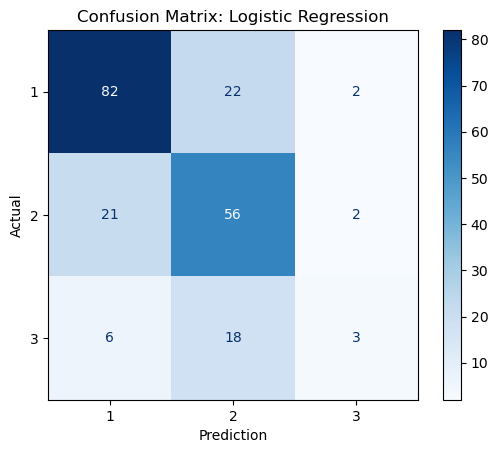

'Random Forest Results:'

,Feature,Gini Importance
5,IllegalFishing,0.168646
13,MaritimeCrime,0.129884
1,FishPop,0.110708
4,ForeignFisher,0.109458
2,EcoChngeOther,0.077208
0,WeakGov,0.065976
3,GroundsLim,0.061268
9,Poverty,0.060179
8,Markets,0.054761
11,Marginalization,0.042615


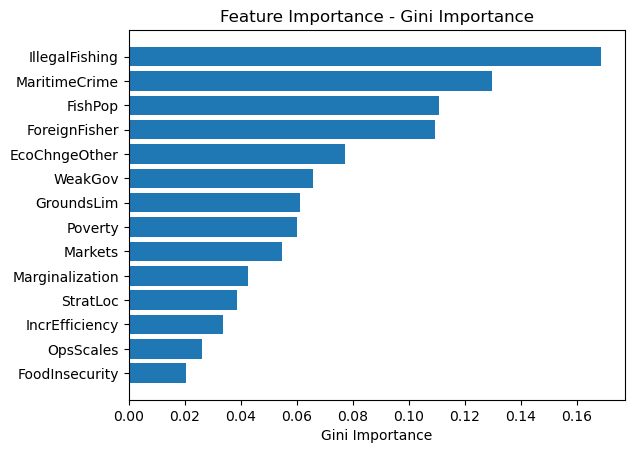

              precision    recall  f1-score   support

           1       0.80      0.78      0.79       106
           2       0.61      0.80      0.69        79
           3       0.60      0.11      0.19        27

    accuracy                           0.70       212
   macro avg       0.67      0.56      0.56       212
weighted avg       0.70      0.70      0.68       212



<Figure size 640x480 with 0 Axes>

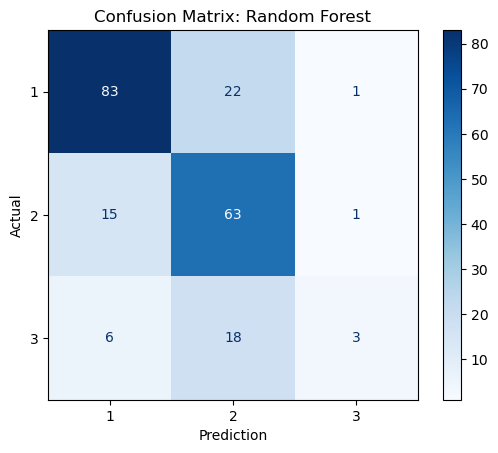

In [96]:
# Run all analysis
def analysis(data, region = None):
    filtered_data = regional_filtering(data, region)
    X_train, X_test, y_train, y_test = split_data(filtered_data)
    results_df, best_models = models(X_train, y_train)
    assessment(best_models, X_train, y_train, X_test, y_test)

analysis(data)

## Forward selection

In [ ]:
# RF forward selection: https://www.youtube.com/watch?v=POCvLGRLDzM

## NOAA Sea Surface Temperature Dataset

In [3]:
import os
import requests

sst_dir = "data/SST"
sst_file = os.path.join(sst_dir, "sst.mnmean.nc")

# A global monthly SST analysis from 1854-present derived from ICOADS data with missing data filled in by statistical methods
sst_download_url = (
    "https://downloads.psl.noaa.gov/Datasets/noaa.ersst.v5/sst.mnmean.nc"
)

os.makedirs(sst_dir, exist_ok=True)

if not os.path.exists(sst_file):
    print("Downloading NOAA ERSST v5 SST file...")
    
    response = requests.get(sst_download_url, stream=True)
    response.raise_for_status()
    
    with open(sst_file, "wb") as f:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
    
    print("Download complete:", sst_file)
else:
    print("SST file already exists:", sst_file)

SST file already exists: data/SST\sst.mnmean.nc


In [4]:
import xarray as xr

sst_ds = xr.open_dataset(sst_file, engine="netcdf4")
sst_ds


<xarray.Dataset> Size: 133MB
Dimensions:    (lat: 89, lon: 180, time: 2069, nbnds: 2)
Coordinates:
  * lat        (lat) float32 356B 88.0 86.0 84.0 82.0 ... -84.0 -86.0 -88.0
  * lon        (lon) float32 720B 0.0 2.0 4.0 6.0 ... 352.0 354.0 356.0 358.0
  * time       (time) datetime64[ns] 17kB 1854-01-01 1854-02-01 ... 2026-05-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 33kB ...
    sst        (time, lat, lon) float32 133MB ...
Attributes: (12/37)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...                        ...
    creator_url_original:      https://www.ncei.noaa.gov
    license:                   No constraints on data access or use
    comment:                   SSTs were observed by conventional thermometer...
    summary:                   ERSST.v5 is developed based on v4 after revisi...
    dataset_title:             NOAA Extended Reconstructed SST V5
    data_modified:             2026-06-03

In [ ]:
# inspect SST variable
sst_ds["sst"]

<xarray.DataArray 'sst' (time: 2069, lat: 89, lon: 180)> Size: 133MB
[33145380 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 356B 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time     (time) datetime64[ns] 17kB 1854-01-01 1854-02-01 ... 2026-05-01
Attributes:
    long_name:     Monthly Means of Sea Surface Temperature
    units:         degC
    var_desc:      Sea Surface Temperature
    level_desc:    Surface
    statistic:     Mean
    dataset:       NOAA Extended Reconstructed SST V5
    parent_stat:   Individual Values
    actual_range:  [-1.8     42.32636]
    valid_range:   [-1.8 45. ]

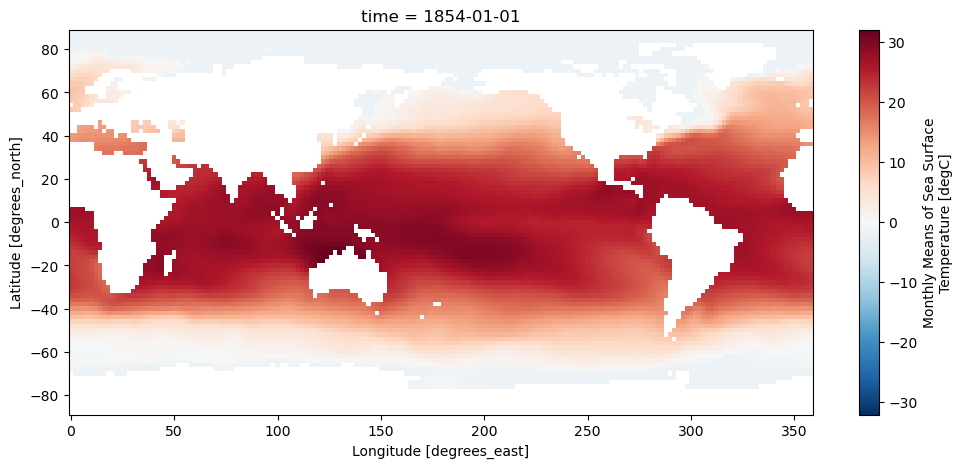

In [6]:
# look at one month's SST variable
sst_ds["sst"].isel(time=0).plot(figsize=(12,5))

In [19]:
# verify WWF dates
print(df["date"].min())
print(df["date"].max())

1990-07-18 00:00:00
2024-10-11 12:00:00


In [ ]:
# verify coordinates
print(df["latitude"].describe())

print(df["longitude"].describe())

count    1058.000000
mean       10.676931
std        22.797553
min       -28.525000
25%        -2.185479
50%         1.573850
75%        13.475002
max        84.791805
Name: latitude, dtype: float64
count    1058.000000
mean       23.097110
std        89.204709
min      -179.941587
25%        33.000000
50%        39.662539
75%        49.129151
max       179.914209
Name: longitude, dtype: float64


In [ ]:
def haversine_km(lat1, lon1, lat2, lon2):
    """
    Great-circle distance between two latitude/longitude points (km).
    """
    lon1 = ((lon1 + 180) % 360) - 180
    lon2 = ((lon2 + 180) % 360) - 180

    R = 6371

    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2)

    return 2 * R * np.arcsin(np.sqrt(a))


def add_sst_to_events(
    events_df,
    sst_ds,
    date_col="date",
    lat_col="latitude",
    lon_col="longitude",
    max_radius_deg=10):
    """
    Add monthly NOAA ERSST sea surface temperature to event data.

    If the nearest ERSST grid cell is land, the search expands outward
    until the first radius containing valid ocean pixels is found.
    The nearest ocean pixel within that radius is then selected.

    Returns a copy of the dataframe with:

        sst_time
        lon_360
        matched_sst_lat
        matched_sst_lon
        sst_degC
        sst_search_radius_deg
        sst_distance_km
    """

    df_sst = events_df.copy()

    df_sst[date_col] = pd.to_datetime(
        df_sst[date_col],
        errors="coerce")

    df_sst["sst_time"] = (
        df_sst[date_col]
        .dt.to_period("M")
        .dt.to_timestamp())

    df_sst["lon_360"] = df_sst[lon_col] % 360

    lookup = (
        df_sst[
            ["sst_time", lat_col, "lon_360"]
        ]
        .dropna()
        .drop_duplicates()
        .reset_index(drop=True))

    sst_subset = sst_ds.sel(
        time=slice(
            lookup["sst_time"].min(),
            lookup["sst_time"].max()))

    def lookup_sst(row):

        event_time = row["sst_time"]
        event_lat = row[lat_col]
        event_lon = row["lon_360"]

        sst_month = sst_subset["sst"].sel(
            time=event_time,
            method="nearest")

        for radius in range(0, max_radius_deg + 1, 2):

            lat_min = event_lat - radius
            lat_max = event_lat + radius
            lon_min = event_lon - radius
            lon_max = event_lon + radius

            lat_slice = slice(lat_max, lat_min)

            if lon_min < 0:

                candidate = xr.concat(
                    [
                        sst_month.sel(
                            lat=lat_slice,
                            lon=slice(lon_min % 360, 358)),
                        sst_month.sel(
                            lat=lat_slice,
                            lon=slice(0, lon_max))
                    ],
                    dim="lon")

            elif lon_max > 358:

                candidate = xr.concat(
                    [
                        sst_month.sel(
                            lat=lat_slice,
                            lon=slice(lon_min, 358)),
                        sst_month.sel(
                            lat=lat_slice,
                            lon=slice(0, lon_max % 360))
                    ],
                    dim="lon")

            else:

                candidate = sst_month.sel(
                    lat=lat_slice,
                    lon=slice(lon_min, lon_max))

            valid = candidate.where(
                ~np.isnan(candidate),
                drop=True)

            if valid.size > 0:

                valid_df = (
                    valid
                    .to_dataframe(name="sst_degC")
                    .reset_index()
                    .dropna(subset=["sst_degC"]))

                # Among the first successful search radius,
                # choose the closest ocean pixel.

                valid_df["sst_distance_km"] = valid_df.apply(
                    lambda x: haversine_km(
                        event_lat,
                        event_lon,
                        x["lat"],
                        x["lon"]),
                    axis=1)

                closest = valid_df.sort_values(
                    "sst_distance_km").iloc[0]

                return pd.Series({

                    "matched_sst_lat":
                        closest["lat"],

                    "matched_sst_lon":
                        closest["lon"],

                    "sst_degC":
                        closest["sst_degC"],

                    "sst_search_radius_deg":
                        radius,

                    "sst_distance_km":
                        closest["sst_distance_km"]})

        return pd.Series({

            "matched_sst_lat": np.nan,
            "matched_sst_lon": np.nan,
            "sst_degC": np.nan,
            "sst_search_radius_deg": np.nan,
            "sst_distance_km": np.nan})

    sst_values = lookup.apply(
        lookup_sst,
        axis=1)

    lookup = pd.concat(
        [lookup, sst_values],
        axis=1)

    df_sst = df_sst.merge(
        lookup,
        on=["sst_time", lat_col, "lon_360"],
        how="left")

    return df_sst

In [44]:
# check if any missing values
df_with_sst_ocean = add_sst_to_events(
    events_df=df,
    sst_ds=sst_ds,
    date_col="date",
    lat_col="latitude",
    lon_col="longitude",
    max_radius_deg=10
)

df_with_sst_ocean["sst_degC"].isna().sum()
# df_with_sst_ocean["sst_distance_km"].describe()

np.int64(3)

In [45]:
df_with_sst_ocean[[
    "date",
    "latitude",
    "longitude",
    "sst_time",
    "matched_sst_lat",
    "matched_sst_lon",
    "sst_degC"]].head()

,date,latitude,longitude,sst_time,matched_sst_lat,matched_sst_lon,sst_degC
0,2011-12-01,-14.27806,-170.70250,2011-12-01,-14.0,190.0,28.764431
1,2011-10-12,-17.53600,-149.58200,2011-10-01,-18.0,210.0,26.528063
2,2011-08-01,13.46000,144.66500,2011-08-01,14.0,144.0,29.538723
3,2011-11-10,13.47567,144.74886,2011-11-01,14.0,144.0,29.095762
4,2011-10-13,-14.47300,178.01800,2011-10-01,-14.0,178.0,28.260935


In [47]:
# summarize missing by region
df_with_sst_ocean.groupby("region")["sst_degC"].apply(
    lambda x: x.isna().mean()
).sort_values(ascending=False)

region
Horn of Africa    0.004386
Arctic            0.000000
Oceania           0.000000
South America     0.000000
South Asia        0.000000
Name: sst_degC, dtype: float64

In [49]:
# inspect match distance
df_with_sst_ocean["sst_distance_km"].describe()

count    1055.000000
mean      250.121051
std       295.109350
min         4.674241
25%        73.729520
50%       106.397837
75%       183.617563
max      1060.150172
Name: sst_distance_km, dtype: float64

In [50]:
# check missing values
df_with_sst_ocean[df_with_sst_ocean["sst_degC"].isna()][
    ["date", "region", "country", "latitude", "longitude", "matched_sst_lat", "matched_sst_lon"]].head(20)

,date,region,country,latitude,longitude,matched_sst_lat,matched_sst_lon
336,2011-04-11,Horn of Africa,Tanzania,-4.429992,29.791667,NaN,NaN
599,2014-11-15,Horn of Africa,Tanzania,-5.680850,29.708213,NaN,NaN
922,1995-09-01,Horn of Africa,Tanzania,-4.839290,29.670720,NaN,NaN


In [51]:
# check events where the matched ocean pixel is far away
df_with_sst_ocean[
    df_with_sst_ocean["sst_distance_km"] > 300
][[
    "date",
    "region",
    "country",
    "latitude",
    "longitude",
    "matched_sst_lat",
    "matched_sst_lon",
    "sst_degC",
    "sst_search_radius_deg",
    "sst_distance_km"]].head(20)

# Coordinates appear to represent inland locations in Tanzania

,date,region,country,latitude,longitude,matched_sst_lat,matched_sst_lon,sst_degC,sst_search_radius_deg,sst_distance_km
167,2001-04-24,Arctic,Russia,55.740010,37.635300,60.0,28.0,0.780685,10.0,739.752591
300,2020-04-17,Arctic,Russia,55.753489,37.596685,60.0,28.0,4.124088,10.0,736.970430
323,2003-08-01,Horn of Africa,Tanzania,-7.136507,35.987220,-8.0,40.0,25.245979,6.0,452.609399
324,2016-10-04,Horn of Africa,Tanzania,-4.966670,34.533330,-4.0,40.0,26.883879,6.0,615.456333
326,2016-09-01,Horn of Africa,Tanzania,-3.300857,31.898988,-4.0,40.0,25.770445,10.0,902.310350
327,2014-12-21,Horn of Africa,Tanzania,-2.506154,32.007492,-4.0,40.0,28.689024,8.0,902.681480
328,2009-11-11,Horn of Africa,Tanzania,-2.502834,32.522055,-4.0,40.0,28.250154,8.0,846.673416
329,2001-09-30,Horn of Africa,Tanzania,-11.517774,34.886492,-8.0,40.0,25.469141,6.0,683.304060
331,2012-10-01,Horn of Africa,Tanzania,-11.517774,34.886492,-8.0,40.0,26.869673,6.0,683.304060
332,2012-10-01,Horn of Africa,Tanzania,-11.517774,34.886492,-8.0,40.0,26.869673,6.0,683.304060


In [52]:
df_with_sst_ocean.head()

,source_file,event_id,date,year,country,region,Location,latitude,longitude,loc_accuracy,...,Summary,Disputed,ForcedLabor,sst_time,lon_360,matched_sst_lat,matched_sst_lon,sst_degC,sst_search_radius_deg,sst_distance_km
0,Oceania_No_AUS_NZL_Final,24328612817,2011-12-01,2011,American Samoa,Oceania,"Pago Pago, capital of American Samoa.",-14.27806,-170.70250,Town,...,"The detention of the San Nikunau, a fishing ve...",0.0,0.0,2011-12-01,189.29750,-14.0,190.0,28.764431,2.0,81.815167
1,Oceania_No_AUS_NZL_Final,24359251958,2011-10-12,2011,French Polynesia,Oceania,"Port of Papeete, French Polynesia.",-17.53600,-149.58200,Town,...,French Polynesian fishermen are engaging in a ...,0.0,0.0,2011-10-01,210.41800,-18.0,210.0,26.528063,2.0,67.978914
2,Oceania_No_AUS_NZL_Final,24349703891,2011-08-01,2011,Guam,Oceania,"Hotel Wharf, Port Authority of Guam.",13.46000,144.66500,Town,...,The dispute between the Port Authority of Guam...,0.0,0.0,2011-08-01,144.66500,14.0,144.0,29.538723,2.0,93.622497
3,Oceania_No_AUS_NZL_Final,24327648295,2011-11-10,2011,Guam,Oceania,"Agana and Agat Marinas, Guam.",13.47567,144.74886,Town,...,The article discusses the enforcement of fishi...,0.0,0.0,2011-11-01,144.74886,14.0,144.0,29.095762,2.0,99.709164
4,Oceania_No_AUS_NZL_Final,24359264846,2011-10-13,2011,High Seas,Oceania,"Pacific high seas, near several Pacific island...",-14.47300,178.01800,International,...,Fijian activists from Greenpeace protested aga...,0.0,0.0,2011-10-01,178.01800,-14.0,178.0,28.260935,2.0,52.630968


<Axes: >

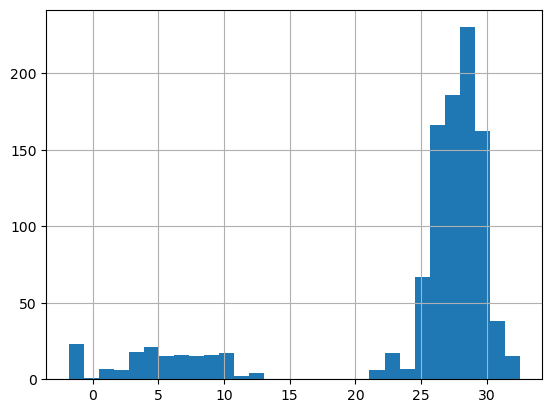

In [ ]:
# inspect SST variable
df_with_sst_ocean["sst_degC"].hist(bins=30)

## References
- Creating a correlation matrix: https://www.geeksforgeeks.org/data-science/create-a-correlation-matrix-using-python/
- different solvers explanation: https://stackoverflow.com/questions/38640109/logistic-regression-python-solvers-definitions
- Logistic regression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- Confusion Matrix chart: https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/
- Feature Importance chart: https://www.geeksforgeeks.org/machine-learning/feature-importance-with-random-forests/
- NOAA Extended Reconstructed SST V5: https://psl.noaa.gov/data/gridded/data.noaa.ersst.v5.html